# Time Series Forecast - ARIMA on-Omellette

### Kumar Rahul

Forecasting the demand of services or products leads to better management of short term or long term planning. In this case, we are looking at the warranty related issues reported, on a particular brand of two-wheeler. The data is a monthly roll-up of approximately half a million issues reported by the customers over a four year period.
We will be using Claim forecasting data in this exercise. Refer the **Exhibit 1** to understand the feature list. Use the data and answer the below questions.

1.	Load the time series dataset in Jupyter Notebook using pandas.
2.	Test stationarity of data using augmented dickey fuller test.
3.	Use data differencing as a strategy to make the data stationary.
4.	Plot the ACF and PACF plot. How will you inspect the plot to arrive at the p-lags and q-lags?
5.	Split the data into training set and test set. Use walk forward validation strategy for model building and evaluation.
6.	Given recent claim, what is the expected claim for the next time period? Build a model with statsmodel.api to forecast the amount claimed in next time step.
7.	Check for validity of model using ACF and PACF plot for error term. What do you observe in these plots?
8.	 How do you interpret the model outcome? Report the model performance on the walk forward validation set.

**Exhibit 1**

|Sl. No.|Name of Variable|Variable Description|
|----------|------------|---------------|
|1	|date	|Date of Claim|
|2	|rate	|Amount claimed|
|3	|item	|Number of claims|



In [2]:
import pandas as pd
import numpy as np
import warnings
from math import sqrt
from numpy import array
from matplotlib import pyplot

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm

In [2]:
# from google.colab import drive
# drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [8]:
monthly_raw_df = pd.read_csv('apollo_breakfast.csv', sep=',', header=0,
                             low_memory=False) #infer_datetime_format=True,)
monthly_raw_df.head()

,Date,BKFST_OCCUP,Idly,Dosa,Chutney,Sambar,Continental B/F,North Indian B/F,Omellette,D-O
0,10/1/12,250,40,30,95,95,25,6,15,-8
1,10/2/12,236,65,33,120,120,25,2,7,1
2,10/3/12,244,59,21,119,120,25,2,8,2
3,10/4/12,239,65,42,140,150,35,5,10,3
4,10/5/12,221,70,26,126,126,41,3,13,-8


In [10]:
monthly_raw_df.sort_index(inplace=True)
monthly_raw_df.columns = monthly_raw_df.columns.str.lower().str.replace(' ', '_')
monthly_raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   date              115 non-null    object
 1   bkfst_occup       115 non-null    int64 
 2   idly              115 non-null    int64 
 3   dosa              115 non-null    int64 
 4   chutney           115 non-null    int64 
 5   sambar            115 non-null    int64 
 6   continental_b/f   115 non-null    int64 
 7   north_indian_b/f  115 non-null    int64 
 8   omellette         115 non-null    int64 
 9   d-o               115 non-null    int64 
dtypes: int64(9), object(1)
memory usage: 9.1+ KB


In [12]:
monthly_raw_df.head()

,date,bkfst_occup,idly,dosa,chutney,sambar,continental_b/f,north_indian_b/f,omellette,d-o
0,10/1/12,250,40,30,95,95,25,6,15,-8
1,10/2/12,236,65,33,120,120,25,2,7,1
2,10/3/12,244,59,21,119,120,25,2,8,2
3,10/4/12,239,65,42,140,150,35,5,10,3
4,10/5/12,221,70,26,126,126,41,3,13,-8


In [24]:
monthly_raw_df['date'] = pd.to_datetime(monthly_raw_df['date'], format="%m/%d/%y").dt.strftime("%Y-%m-%d")


In [30]:
monthly_raw_df.head()

,date,bkfst_occup,idly,dosa,chutney,sambar,continental_b/f,north_indian_b/f,omellette,d-o
0,2012-10-01,250,40,30,95,95,25,6,15,-8
1,2012-10-02,236,65,33,120,120,25,2,7,1
2,2012-10-03,244,59,21,119,120,25,2,8,2
3,2012-10-04,239,65,42,140,150,35,5,10,3
4,2012-10-05,221,70,26,126,126,41,3,13,-8


In [80]:
monthly_filter_df = monthly_raw_df.filter(['omellette'], axis =1)
#monthly_filter_df['rate'] = monthly_filter_df['rate'].map(lambda x:str(x).replace(',', '')).astype(float)

In [86]:
# Ensure 'Date' column is in datetime format
monthly_raw_df['date'] = pd.to_datetime(monthly_raw_df['date'])

# Set 'Date' as the index and keep 'Omellette' as the first-axis column
monthly_filter_df = monthly_raw_df.set_index('date')[['omellette']]

In [88]:
monthly_filter_df.head()

,omellette
date,
2012-10-01,15
2012-10-02,7
2012-10-03,8
2012-10-04,10
2012-10-05,13


In [ ]:
# monthly_filter_df = monthly_filter_df[(monthly_filter_df.index >="2012-10-01") &
#                                       (monthly_filter_df.index <= "2013-01-23")]

# monthly_filter_df.info()

In [54]:
# date_range = pd.date_range(start="2012-10-01", end="2013-12-24", freq='D')  # Daily frequency
# monthly_filter_df = pd.DataFrame({'omellette': range(len(date_range))}, index=date_range)

In [ ]:
# monthly_filter_df = monthly_filter_df[(monthly_filter_df.index >='2012-10-01') &
#                                       (monthly_filter_df.index <= '2013-13-24')]

# monthly_filter_df.info()

## Problem Framing


We will use the data to explore a very specific question; that is:

**Given recent claim, what is the expected claim for the next time period?**

Plot of the original data is shown below:

Text(0.5, 1.0, 'omellette')

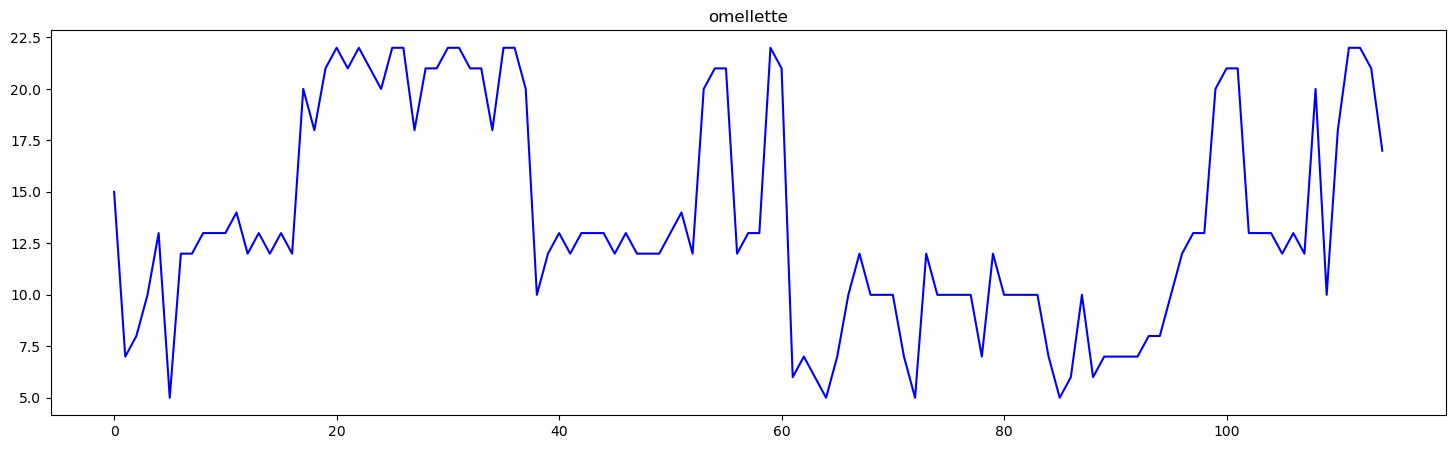

In [68]:
pyplot.figure(figsize = (18, 5))
pyplot.plot(monthly_filter_df['omellette'], 'b-')
pyplot.title('omellette')

## Stationarity

We can assume the series to be stationary if it has constant statistical properties over time, i.e. the following:

> 1. constant mean - The mean of the series should not be a function of time rather should be a constant.
2. constant variance - The variance of the series should not a be a function of time. This property is known as homoscedasticity.
3. an autocovariance that does not depend on time - The covariance of the i th term and the (i + m) th term should not be a function of time.

More formally, we can check stationarity using the following:

> Dickey-Fuller Test: This is one of the statistical tests for checking stationarity.

* Here the null hypothesis is that the TS is non-stationary (have unit root). It has some time-dependent structure and does not have constant variance over time.
* The test results comprise of a Test Statistic and some Critical Values for difference confidence levels.
* If the Test Statistic is less than the Critical Value, we can reject the null hypothesis and say that the series is stationary.


The below function which takes a timeseries data as input and perform the Dickey-Fuller test to check stationarity:

In [44]:
from statsmodels.tsa.stattools import adfuller
def df_test(data, lag, reg):
    #Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    #dftest = adfuller(data,maxlag=lag, autolag='t-stat')
    dftest = adfuller(data.iloc[:,0].values, maxlag=lag, autolag='t-stat', regression = reg)
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

* When performing a Dickey-Fuller test, we should not test at lag 0; instead, we should choose a lag value greater than 0, typically using the default lag selection method provided by the statsmodels library, which usually calculates an appropriate lag based on your data size. A lag of 0 would essentially mean not including any lagged information in the model, which is not how the Dickey-Fuller test is designed to work.

* The "lag value" refers to the number of lagged differences of the time series that are included in the regression equation, essentially representing how many past periods of the data are considered when testing for stationarity; a higher lag value means more past data is taken into account to adjust for potential autocorrelations in the series.

In [10]:
?adfuller

In [90]:
df_test(monthly_filter_df,None, reg='n')

Results of Dickey-Fuller Test:
Test Statistic                  -0.284441
p-value                          0.582058
#Lags Used                       3.000000
Number of Observations Used    111.000000
Critical Value (1%)             -2.586177
Critical Value (5%)             -1.943670
Critical Value (10%)            -1.614629
dtype: float64


The augmented Dickey–Fuller (ADF) statistic is a negative number. The more negative the number, the stronger the rejection of the null hypothesis that there is a unit root at some level of confidence.3 period lagged value (AR model was built); the p-value suggests that the original series is non stationary.



### Make time series stationary

There are 2 major reasons behind non-stationarity of a time series data:

> * Trend – varying mean over time. In this case we can see that on average, the claim is varying  over time.
* Seasonality – variations at specific time-frames. In this case, claim might be high during some time period owing to climatic conditions leading to wear and tear.


The underlying principle is to estimate the trend and seasonality in the series and remove those from the series to get a stationary series. Then statistical forecasting techniques can be implemented on the filtered series. The final step would be to convert the forecasted values into the original scale by applying trend and seasonality constraints back.

### Identify and Eliminate Trend and Seasonality

The simple trend reduction techniques discussed before don’t work in all cases, particularly the ones with high seasonality. Two widely used techniques of removing trend and seasonality:

> * Differencing – taking the differece with a particular time lag
* Decomposition – modeling both trend and seasonality and removing them from the model. We will not be discussing this technique

#### Differencing
One of the most common methods of dealing with both trend and seasonality is differencing. In this technique, the difference of the observation at a particular instant with that at the previous instant is taken. This mostly works well in improving stationarity. First order differencing can be done in Pandas as:

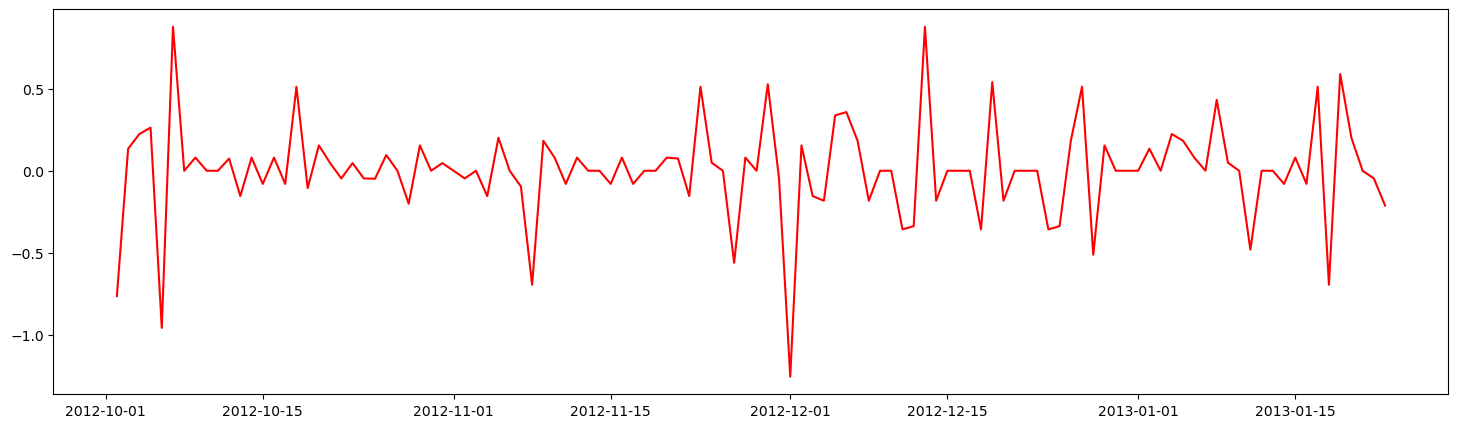

In [92]:
monthly_filter_log_df = np.log(monthly_filter_df['omellette'])
monthly_filter_diff_log_df = monthly_filter_log_df - monthly_filter_log_df.shift(1)
#monthly_filter_diff_df = monthly_filter_df - monthly_filter_df.shift(1)
monthly_filter_diff_log_df= monthly_filter_diff_log_df.dropna().reset_index()
monthly_filter_diff_log_df.set_index('date', inplace=True)

pyplot.figure(figsize = (18, 5))
diff = pyplot.plot(monthly_filter_diff_log_df, color='red',label='Difference')


In [94]:
monthly_filter_diff_log_df.head()

,omellette
date,
2012-10-02,-0.762140
2012-10-03,0.133531
2012-10-04,0.223144
2012-10-05,0.262364
2012-10-06,-0.955511


This appears to have reduced trend considerably. The test shows that no lagged value was used to make the series stationary. So the original series is stationary.

In [14]:
df_test(monthly_filter_diff_log_df,None,'n')

Results of Dickey-Fuller Test:
Test Statistic                 -2.186449
p-value                         0.027642
#Lags Used                      3.000000
Number of Observations Used    34.000000
Critical Value (1%)            -2.634636
Critical Value (5%)            -1.951017
Critical Value (10%)           -1.610711
dtype: float64


Do not do further differencing if level 1 differencing makes the series statioanry. Since for this dataset, the time series is stationary we can set d = 1 and will find the value of p and q using ACF and PACF plot.

## Autocorrelation Analysis

We can assume the distribution of each variable fits a Gaussian (bell curve) distribution. If this is the case, we can use the Pearson’s correlation coefficient to summarize the correlation between the variables.

The Pearson’s correlation coefficient is a number between -1 and 1 that describes a negative or positive correlation respectively. A value of zero indicates no correlation.

We can calculate the correlation for time series observations with observations with previous time steps, called lags. Because the correlation of the time series observations is calculated with values of the same series at previous times, this is called a serial correlation, or an autocorrelation.

A plot of the autocorrelation of a time series by lag is called the AutoCorrelation Function, or the acronym ACF. This plot is sometimes called a correlogram, or an autocorrelation plot.

A partial autocorrelation function or PACF is a summary of the relationship between an observation in a time series with observations at prior time steps with the relationships of intervening observations removed.

The autocorrelation for an observation and an observation at a prior time step is comprised of both the direct correlation and indirect correlations. These indirect correlations are a linear function of the correlation of the observation, with observations at intervening time steps.

It is these indirect correlations that the partial autocorrelation function seeks to remove. This is the intuition for the partial autocorrelation.

We can calculate autocorrelation and partial autocorrelation plots using the plot_acf() and plot_pacf() statsmodels functions respectively.

ACF and PACF plot for the monthly data

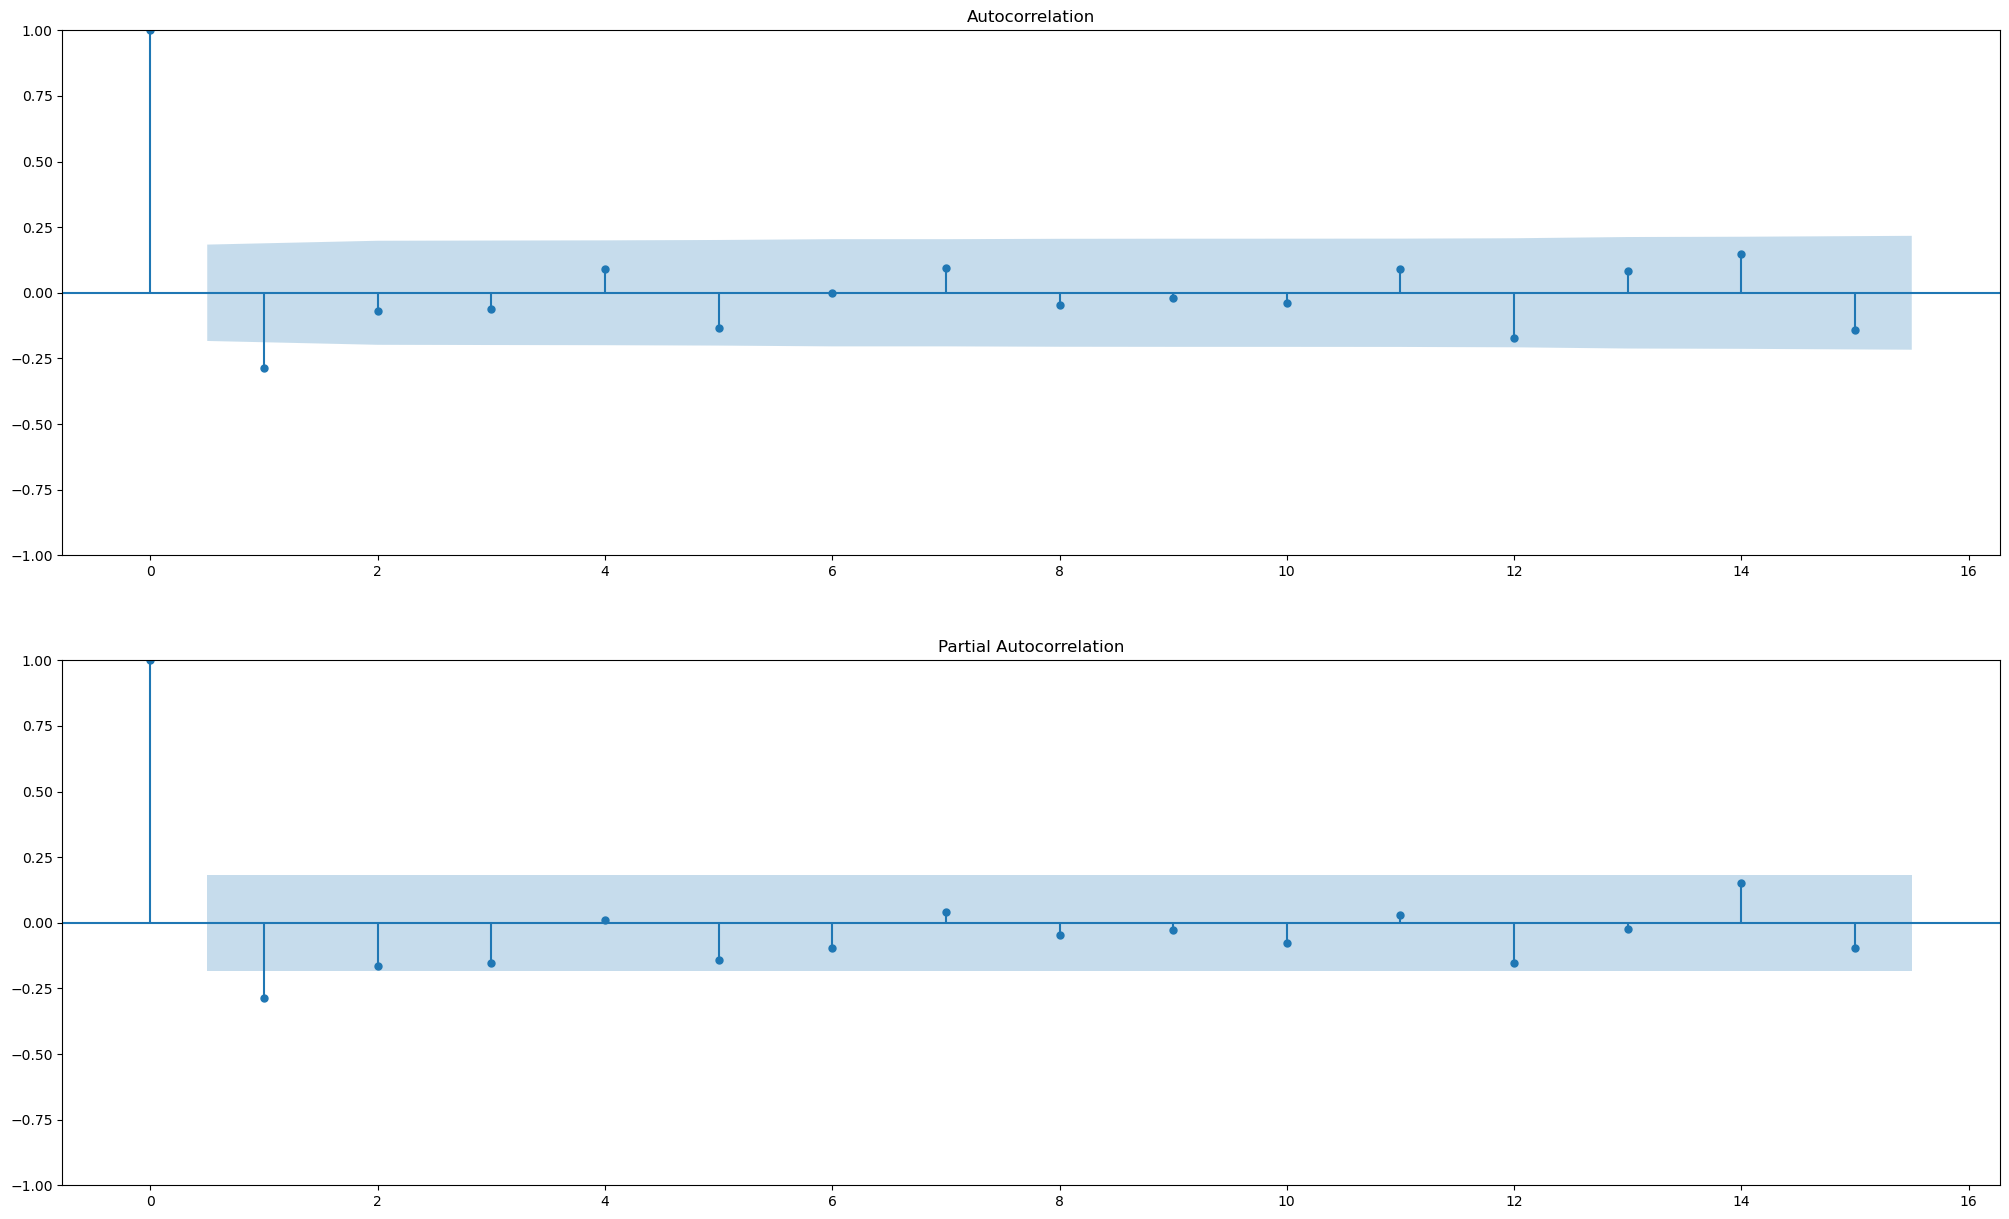

In [96]:
# plots
pyplot.figure(figsize = (25, 15))
lags = 15
# acf
axis = pyplot.subplot(2, 1, 1)
plot_acf(monthly_filter_diff_log_df, ax=axis, lags=lags) #monthly_filter_diff_log_df or monthly_filter_df
# pacf
axis = pyplot.subplot(2,1,2)
plot_pacf(monthly_filter_diff_log_df, ax=axis, lags=lags)
# show plot
pyplot.show()

The PACF plot which cuts to zero (in the shaded region at a lag of 1). So the value of 'p' is 0 (the correlation between Y and Y(t-1) was not signifcant; so it should not be included in the model). The ACF plot is used to understand the value of 'q' which should be 0 here. So effectively we are building an ARIMA(0,1,0) model. 0 AR term and 0 MA terms.

## Train and Test Sets
We will use the first three years of data for training predictive models and the final year for evaluating models.

The function split_filter_df() below splits the monthly data into train and test sets and organizes each into standard weeks.

Specific row offsets are used to split the data using knowledge of the filter_df. The split filter_dfs are then organized into  data using the NumPy split() function.

In [98]:
def split_filter_df(data):
    split_point = len(data) - 10
    train, test = data[0:split_point], data[split_point:]
    return train, test

In [100]:
# load the new file
train, test = split_filter_df(monthly_filter_diff_log_df) #monthly_filter_diff_log_df or monthly_filter_df

In [102]:
# validate train data
print(train.shape)
train.head()

(104, 1)


,omellette
date,
2012-10-02,-0.762140
2012-10-03,0.133531
2012-10-04,0.223144
2012-10-05,0.262364
2012-10-06,-0.955511


In [104]:
# validate test data
print(test.shape)
test.head()

(10, 1)


,omellette
date,
2013-01-14,-0.080043
2013-01-15,0.080043
2013-01-16,-0.080043
2013-01-17,0.510826
2013-01-18,-0.693147


In [197]:
## A simple arima model with the pdq identified above
p, d, q = 1, 0, 1
model = ARIMA(train["omellette"], order=(p, d, q))
model_fit = model.fit()
model_fit.forecast(steps=1)[0]

13.036523064491082

## Evaluation Metric

Both Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE) can be used. Unlike MAE, RMSE is more punishing of forecast errors.

The function evaluate_forecasts_rmse() and evaluate_forecasts_mape() is being used for evaluating model performance.

In [200]:
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import root_mean_squared_error

In [202]:
# evaluate one or more  forecasts against expected values
def evaluate_forecasts_rmse(actual):
    #score_rmse = 0
    #se = 0
    #calculate an RMSE score for each day
    #for i in range(actual.shape[0]):
    #    # calculate mse
    #    se += (actual.iloc[i,0] - actual.iloc[i,1])**2
    #    # calculate rmse
    #score_rmse = sqrt(se/actual.shape[0])
    score_rmse= root_mean_squared_error(actual['omellette'], actual['prediction'])
    return score_rmse

In [204]:
# evaluate one or more  forecasts against expected values
def evaluate_forecasts_mape(actual):
    #score_mape = 0
    #ape = 0
    #for i in range(actual.shape[0]):
    #    # calculate mse
    #    ape += np.abs(((actual.iloc[i,0] - actual.iloc[i,1])/actual.iloc[i,0]))
    #    # calculate mape
    #score_mape = (ape)/actual.shape[0]
    score_mape = mean_absolute_percentage_error(actual['omellette'], actual['prediction'])
    return actual, score_mape

## Walk-Forward Validation
Models will be evaluated using a scheme called walk-forward validation.

This is where a model is required to make a one month prediction, then the actual data for that month is made available to the model so that it can be used as the basis for making a prediction on the subsequent month. This is both realistic for how the model may be used in practice and beneficial to the models, allowing them to make use of the best available data.

A walk-forward validation, or rolling forecast, method is used as follows:

> * Each time step in the test dataset is iterated.
* Within each iteration, a new ARIMA model is trained on all available historical data.
* The model is used to make a prediction for the next time step.
* The prediction is stored and the “real” observation is retrieved from the test set and added to the history for use in the next iteration.
* The performance of the model is summarized at the end by calculating the root mean squared error (RMSE) of all predictions made compared to expected values in the test dataset.


The name of a function is provided for the model as the argument “model_func“. This function is responsible for defining the model, fitting the model on the training data, and making a one-week forecast.

The forecasts made by the model are then evaluated against the test dataset using the previously defined evaluate_forecasts() function.

In [207]:
# evaluate a single model
def evaluate_model(model_func, trn, tst, order):
    ##history is a list of  data
    ##THIS NEEDS CHNAGE BASED ON WHICH COLUMN IS BEING USED
    history = trn.omellette.to_list()
    # walk-forward validation over each week
    predictions = list()
    for i in range(len(tst)):
        # predict the week
        #yhat_sequence = model_func(history, order)
        yhat_sequence = model_func(hist=history, pdq=order).tolist()
        # store the predictions
        predictions.append(yhat_sequence)
        ##KEEP CHECK HERE. IF USING diff_log_rate at INDEX POSITION 2. CHNAGE IF NEEDED
        # get real observation and add to history for predicting the next week
        history.append(tst.iloc[i,0].tolist())
        #print("history updated")
    predictions = array(predictions)
    #print(predictions)
    tst['prediction'] = predictions
    # evaluate predictions days for each week
    actual, score_mape = evaluate_forecasts_mape(tst[:])
    score_rmse = evaluate_forecasts_rmse(tst[:])
    return actual, score_mape, score_rmse

## Develop an Autoregression Model
We can develop an autoregression model for univariate series of monthly claims.

The Statsmodels library provides multiple ways of developing an AR model, such as using the AR, ARMA, ARIMA, and SARIMAX classes.

We will use the ARIMA implementation as it allows for easy expandability into differencing and moving average.

Note: To make holts winter model, use:

> * `import statsmodels.tsa.holtwinters as hw`
* `model = hw.ExponentialSmoothing()`

Help on the model - hw.ExponentialSmoothing.fit?

In [210]:
# arima forecast
def arima_forecast(hist,pdq):
    # define the model
    model = ARIMA(hist, order=pdq)
    # fit the model
    model_fit = model.fit()
    # make forecast
    yhat = model_fit.forecast(steps=1)[0]
    return yhat

In [212]:
def del_column(test):
    for n in test.columns:
        if n =='prediction':
            test.drop('prediction', axis = 1, inplace=True)

In [214]:
# define the names and functions for the models we wish to evaluate
models = dict()
models['arima'] = arima_forecast

import itertools
p_values = [0,1,2]
d_values  = [0, 1]
q_values = [0, 1, 2]

pdq = list(itertools.product(p_values, d_values, q_values))
warnings.filterwarnings("ignore")
# evaluate each model
for name, func in models.items():
    best_mape,best_rmse, best_cfg = float("inf"), float("inf"), None
    for pdq in pdq:
        order = pdq
        del_column(test)
        try:
            actual, score_mape, score_rmse= evaluate_model(model_func=func, trn=train, tst=test, order=pdq)
            if score_rmse < best_rmse:
                best_rmse, best_mape, best_cfg = score_rmse, score_mape, order
            print('ARIMA%s MAPE=%.5f RMSE=%.4f' % (order,score_mape,score_rmse))
        except:
            continue
    print('Best ARIMA%s MAPE=%.5f RMSE=%.5f' % (best_cfg,best_mape, best_rmse))

ARIMA(0, 0, 0) MAPE=0.25121 RMSE=5.4379
ARIMA(0, 0, 1) MAPE=0.25441 RMSE=5.2774
ARIMA(0, 0, 2) MAPE=0.25483 RMSE=5.0626
ARIMA(0, 1, 0) MAPE=0.25528 RMSE=5.1381
ARIMA(0, 1, 1) MAPE=0.23049 RMSE=4.5791
ARIMA(0, 1, 2) MAPE=0.24173 RMSE=4.7000
ARIMA(1, 0, 0) MAPE=0.23876 RMSE=4.7601
ARIMA(1, 0, 1) MAPE=0.23119 RMSE=4.5964
ARIMA(1, 0, 2) MAPE=0.23802 RMSE=4.6717
ARIMA(1, 1, 0) MAPE=0.23951 RMSE=4.7592
ARIMA(1, 1, 1) MAPE=0.23794 RMSE=4.6380
ARIMA(1, 1, 2) MAPE=0.24107 RMSE=4.6872
ARIMA(2, 0, 0) MAPE=0.23192 RMSE=4.6450
ARIMA(2, 0, 1) MAPE=0.23422 RMSE=4.6191
ARIMA(2, 0, 2) MAPE=0.23905 RMSE=4.6767
ARIMA(2, 1, 0) MAPE=0.24468 RMSE=4.8090
ARIMA(2, 1, 1) MAPE=0.24298 RMSE=4.7177
ARIMA(2, 1, 2) MAPE=0.24790 RMSE=4.7703
Best ARIMA(0, 1, 1) MAPE=0.23049 RMSE=4.57907


In [218]:
models = dict()
models['arima'] = arima_forecast
pdq = (1,0,1)
# evaluate each model
for name, func in models.items():

    del_column(test)
    actual, score_mape, score_rmse= evaluate_model(func, train, test, pdq)
    print('ARIMA%s MAPE=%.5f RMSE=%.4f' % (pdq,score_mape,score_rmse))

ARIMA(1, 0, 1) MAPE=0.23119 RMSE=4.5964


In [172]:
actual

,omellette,log_omellette,diff_log_omellette,convert_omellette,prediction
date,,,,,
2013-01-14,12,2.484907,-0.080043,12.0,13.497317
2013-01-15,13,2.564949,0.080043,13.0,12.622758
2013-01-16,12,2.484907,-0.080043,12.0,13.225717
2013-01-17,20,2.995732,0.510826,20.0,12.435093
2013-01-18,10,2.302585,-0.693147,10.0,18.177745
2013-01-19,18,2.890372,0.587787,18.0,11.586522
2013-01-20,22,3.091042,0.200671,22.0,16.480468
2013-01-21,22,3.091042,0.000000,22.0,19.674787
2013-01-22,21,3.044522,-0.046520,21.0,20.386884


## Tranform the data back to original unit

In [175]:
monthly_filter_df['log_omellette'] = np.log(monthly_filter_df['omellette'])
monthly_filter_df['diff_log_omellette'] = monthly_filter_df['log_omellette'] - monthly_filter_df['log_omellette'].shift(1)
#monthly_filter_diff_df = monthly_filter_df - monthly_filter_df.shift(1)
temp = monthly_filter_df['log_omellette'][0]
monthly_filter_df= monthly_filter_df.dropna().reset_index()
monthly_filter_df.set_index('date', inplace=True)
monthly_filter_df.head()

,omellette,log_omellette,diff_log_omellette,convert_omellette
date,,,,
2012-10-03,8,2.079442,0.133531,8.0
2012-10-04,10,2.302585,0.223144,10.0
2012-10-05,13,2.564949,0.262364,13.0
2012-10-06,5,1.609438,-0.955511,5.0
2012-10-07,12,2.484907,0.875469,12.0


To get the original values and prediction. We define a function.

In [178]:
def diff_inv(series_diff, first_value):
    series_inverted = np.r_[first_value,series_diff].cumsum().astype('float64')
    return series_inverted



See it work on the actual data first.

In [181]:
inversed_series = diff_inv(monthly_filter_df.diff_log_omellette , temp)
inversed_series = inversed_series[1:]
monthly_filter_df['convert_omellette'] = np.exp(inversed_series)
monthly_filter_df.head()

,omellette,log_omellette,diff_log_omellette,convert_omellette
date,,,,
2012-10-03,8,2.079442,0.133531,8.0
2012-10-04,10,2.302585,0.223144,10.0
2012-10-05,13,2.564949,0.262364,13.0
2012-10-06,5,1.609438,-0.955511,5.0
2012-10-07,12,2.484907,0.875469,12.0


In [183]:
train, test = split_filter_df(monthly_filter_df) #monthly_filter_diff_log_df or monthly_filter_df

In [185]:
test.head()

,omellette,log_omellette,diff_log_omellette,convert_omellette
date,,,,
2013-01-14,12,2.484907,-0.080043,12.0
2013-01-15,13,2.564949,0.080043,13.0
2013-01-16,12,2.484907,-0.080043,12.0
2013-01-17,20,2.995732,0.510826,20.0
2013-01-18,10,2.302585,-0.693147,10.0


The inverse function was able to reconstruct the actual rate. Converting the prediction using the same function.

In [188]:
inversed_series = diff_inv(actual.prediction , temp)
inversed_series = inversed_series[1:]
test['prediction'] = actual['prediction']
test['convert_prediction'] = np.exp(inversed_series)
test.head()

,omellette,log_omellette,diff_log_omellette,convert_omellette,prediction,convert_prediction
date,,,,,,
2013-01-14,12,2.484907,-0.080043,12.0,13.497317,5.092232e+06
2013-01-15,13,2.564949,0.080043,13.0,12.622758,1.544907e+12
2013-01-16,12,2.484907,-0.080043,12.0,13.225717,8.565611e+17
2013-01-17,20,2.995732,0.510826,20.0,12.435093,2.154025e+23
2013-01-18,10,2.302585,-0.693147,10.0,18.177745,1.689449e+31


In [190]:
#mean_absolute_percentage_error(test['rate'], test['convert_prediction'])

print(mean_absolute_percentage_error(test['convert_omellette'], test['convert_prediction']))
print(root_mean_squared_error(test['convert_omellette'], test['convert_prediction']))


2.213286620814468e+67
1.189834560539231e+69


## Plot the ACF and PACF plot of the error

The ACF and PACF plot of the error should cut to zero.

In [193]:
test['error']= test.convert_omellette-test.convert_prediction

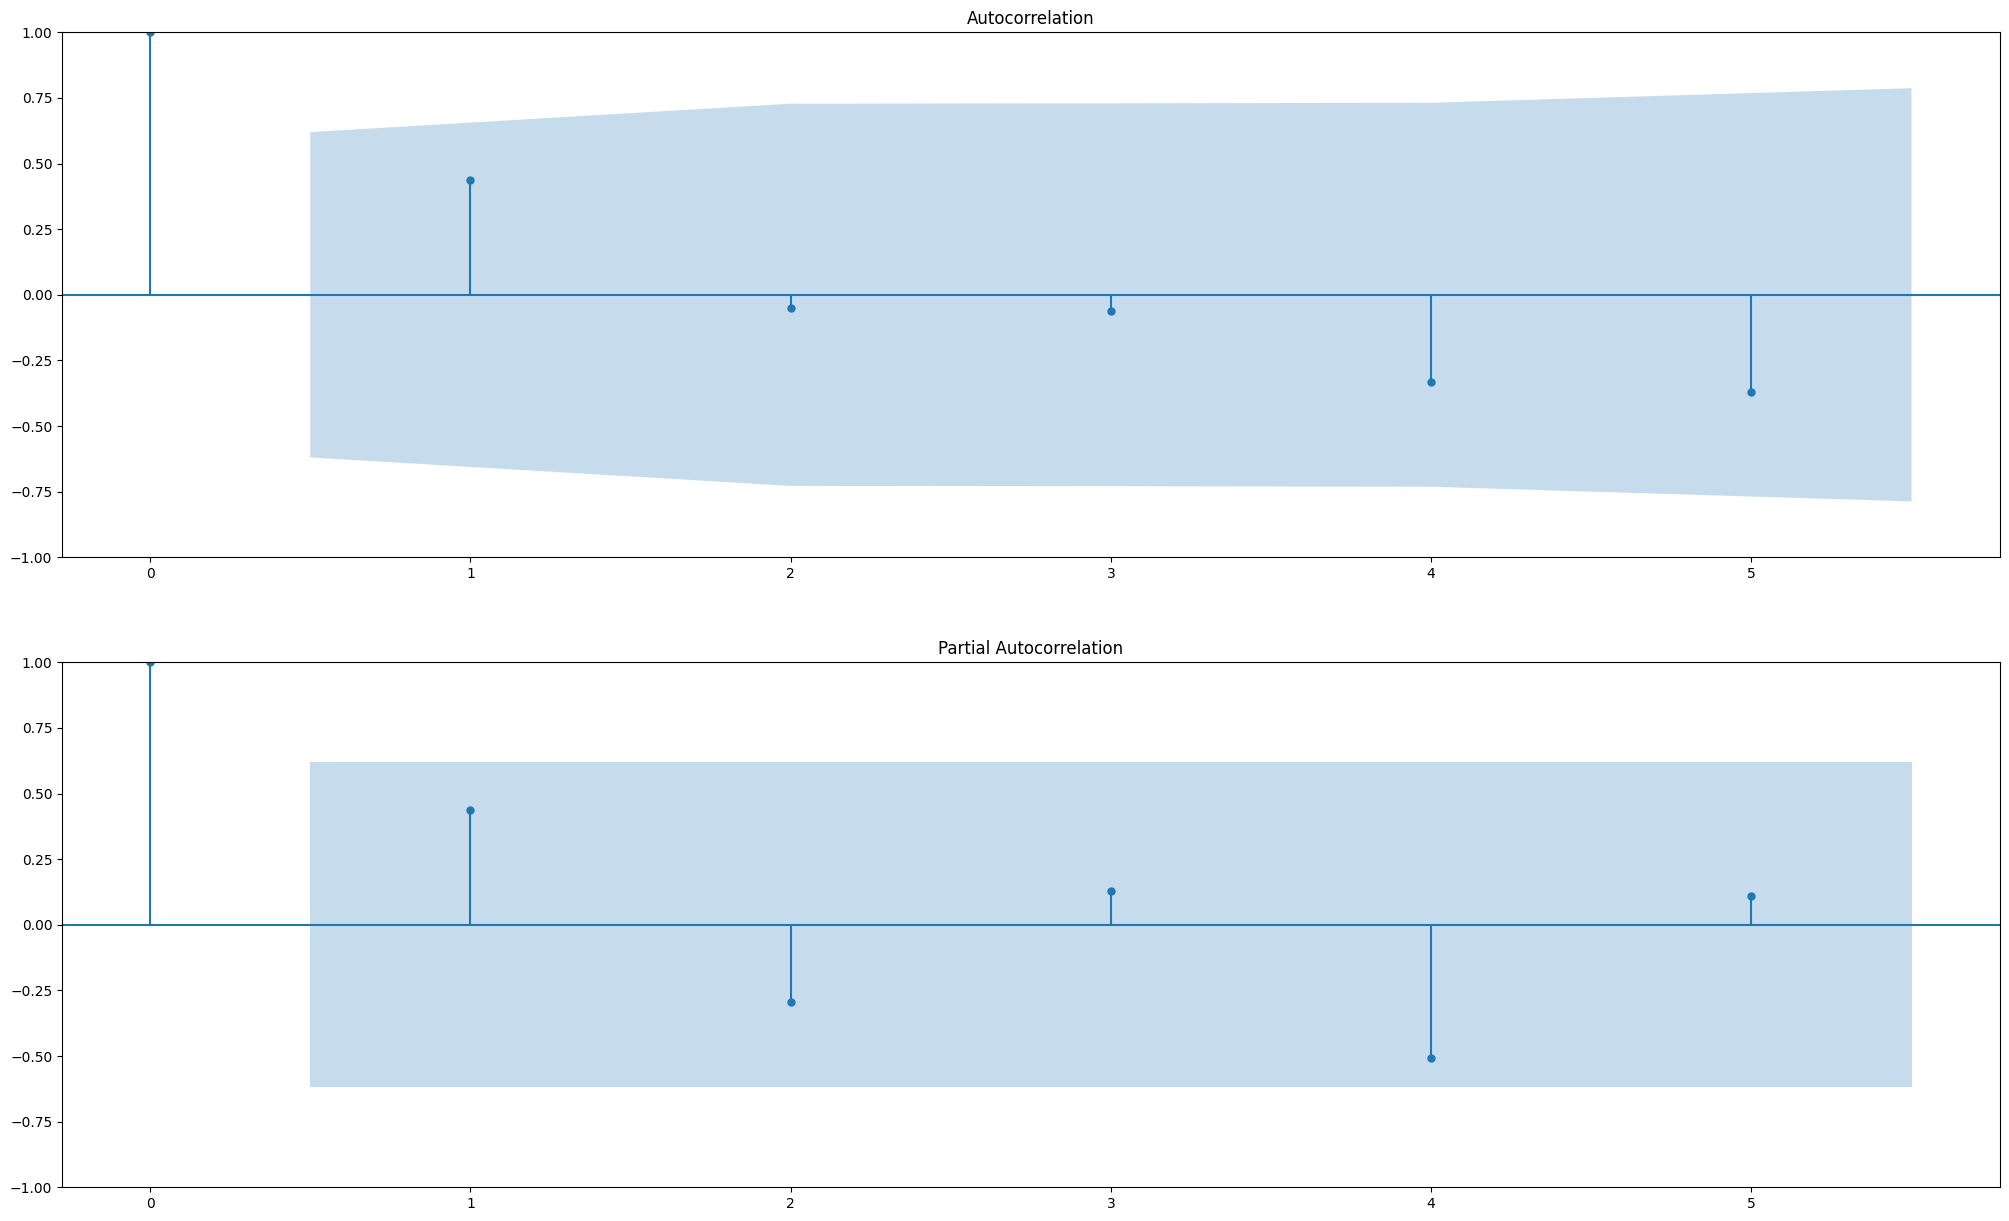

In [38]:
# plots
pyplot.figure(figsize = (25, 15))
lags = 5
# acf
axis = pyplot.subplot(2, 1, 1)
plot_acf(test.error, ax=axis, lags=lags)
# pacf
axis = pyplot.subplot(2,1,2)
plot_pacf(test.error, ax=axis, lags=lags)
# show plot
pyplot.show()